## Analysis

This notebook is to analyze the "N choose 2" method where all bins are compared with all other bins. 

In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import datetime
import sys
sys.path.append("../discretized-causalpfn")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

from discretize import DataDiscretizer
from inference import DiscreteCausalPFN
from scipy.interpolate import interp1d

In [2]:
# RMSE function
def calculate_rmse(y_pred, y_true):
    result = np.mean(np.power(y_pred - y_true, 2))
    result = np.sqrt(result)

    return result

fine_t_mesh = np.linspace(0, 1, 100)

In [8]:
## LOAD DATA

df_linear = pd.read_csv(
    "../output/11-21/EPO_df_vahid-linear_uniform_all_11-21_11h20m.csv",
    index_col=[0, 1]
)

df_nonlin = pd.read_csv(
    "../output/11-21/EPO_df_vahid-nonlinear_uniform_all_11-21_11h31m.csv",
    index_col=[0, 1]
)

df_econML = pd.read_csv(
    "../output/11-21/EPO_df_econ-ML-ex1_uniform_all_11-21_11h27m.csv",
    index_col=[0, 1]
)

df_debt = [] # fill later

df_admit = pd.read_csv(
    "../output/11-21/EPO_df_ADMIT-synthetic_uniform_all_11-21_11h37m.csv"
)

## Uniform binning (with N choose 2 method)

Change the information in the cell below to run the data analysis & viz on different datasets

In [46]:
df = df_nonlin # load dataset
data_name = "vahid-nonlin" # REMEMBER TO CHANGE THIS TOO
def drf_true(t): return 0.5 * t ** 2 - 2 * t # true dose-response function, change this too
save_data = False # Make this True to save output figures and csv 

In [47]:
N_max = df.index[-1][0]
scheme = "uniform"
comparison_method = "all"

In [48]:
# For file naming purposes
month = datetime.datetime.now().month
date = datetime.datetime.now().day
hour = datetime.datetime.now().hour
minute = datetime.datetime.now().minute
date_string = f"{month}-{date}_{hour}h{minute}m"
file_location = "../output/11-21"

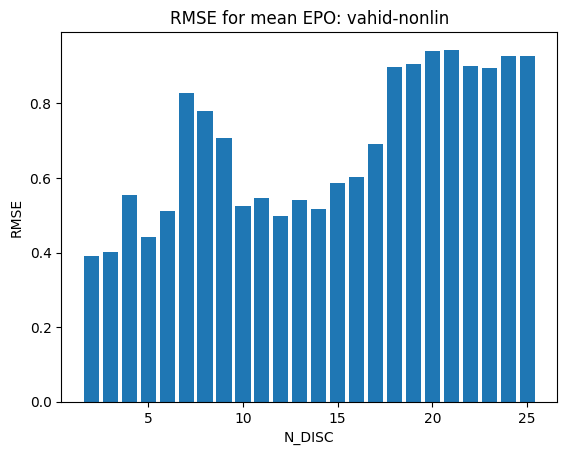

In [49]:
# RMSE calculation on the average EPO
rmse_dict = dict()
for N_DISC in range(2, N_max + 1):
    df_N = df.loc[[N_DISC]]
    drf_N_pred_pts = df_N["estimated_epo"].values
    t_vals = df_N.index.get_level_values(1) # get treatment values
    drf_N_pred = interp1d(t_vals, drf_N_pred_pts,
                          bounds_error=False,
                          fill_value=(drf_N_pred_pts[0], drf_N_pred_pts[-1]))
    y_pred = drf_N_pred(fine_t_mesh)
    y_true = drf_true(fine_t_mesh)
    error = calculate_rmse(y_pred, y_true)
    rmse_dict[N_DISC] = np.round(error, 5)

# Create DataFrame and plot
rmse_df = pd.DataFrame.from_dict(rmse_dict, orient="index", columns=["RMSE"])
fig = plt.figure()
plt.bar(rmse_df.index, height=rmse_df["RMSE"])
plt.xlabel("N_DISC")
plt.ylabel("RMSE")
plt.title(f"RMSE for mean EPO: {data_name}")

if save_data:
    rmse_df.to_csv(f"{file_location}/RMSE_table_{data_name}_{scheme}_{comparison_method}_{date_string}.csv") # save df
    plt.savefig(f"{file_location}/RMSE_bar_chart_{data_name}_{scheme}_{comparison_method}_{date_string}.png")

plt.show()

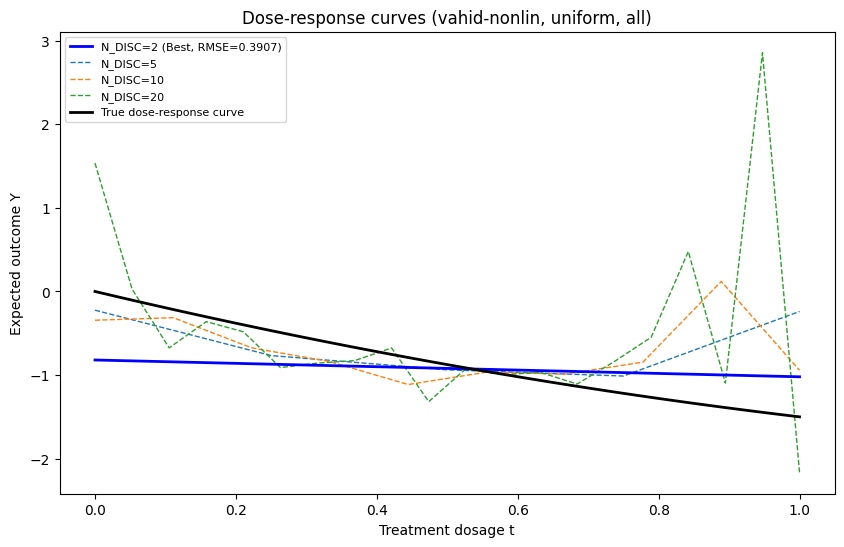

In [51]:
## Plotting DRF predictions
fig = plt.figure(figsize=(10, 6))

N_DISC_TO_VIZ = [2, 5, 10, 20]
for N_DISC in N_DISC_TO_VIZ:
    df_N = df.loc[[N_DISC]]
    t_vals = df_N.index.get_level_values(1) # get treatment values
    y_pred = df_N["estimated_epo"].values
    rmse = rmse_df.loc[N_DISC, "RMSE"]
    if rmse == rmse_df.min().values: # emphasize best prediction
        plt.plot(t_vals, y_pred, '-', linewidth=2,
                 label=f"N_DISC={N_DISC} (Best, RMSE={rmse:.4f})", c="blue", zorder=14)
    else:
        plt.plot(t_vals, y_pred, '--', linewidth=1,
                 label=f"N_DISC={N_DISC}")

# True dose-response curve
t_mesh = np.linspace(0, 1, 100)
y_true = drf_true(t_mesh)
plt.plot(t_mesh, y_true,
         label="True dose-response curve", linewidth=2, c='k', zorder=15)

plt.title(f"Dose-response curves ({data_name}, {scheme}, {comparison_method})")
plt.xlabel("Treatment dosage t")
plt.ylabel("Expected outcome Y")
plt.legend(fontsize=8)

if save_data:
    plt.savefig(f"{file_location}/dose-response_curves_{data_name}_{scheme}_{comparison_method}_{date_string}.png")

plt.show()